# Projet Vélib 2026

## Estimation de la probabilité qu'une station soit vide à l'état stationnaire

*Rapport de projet — Files d'attente*

## 1. Introduction

On considère un système de vélo partagé de type Vélib composé de $J = 5$ stations (numérotées de 3 à 7) et de $N$ vélos. L'objectif est d'estimer la **probabilité qu'une station soit vide** à l'état stationnaire.

**Démarche :**
1. **Modélisation** : construction d'un modèle markovien (processus de migration fermé, cf. Kelly & Yudovina, section 2.3).
2. **Analyse théorique** : calcul exact de la distribution stationnaire pour $N = 1$ vélo et 5 stations.
3. **Simulation** : implémentation d'un simulateur de processus de Markov en temps continu, validation pour $N = 1$, puis exécution pour $N = 100$ vélos.

## 2. Données

Les paramètres sont issus du fichier `velib_data_simulation.xlsx`.

- **Matrice de routage** $P$ : probabilité qu'un usager partant de la station $j$ se dirige vers la station $k$.
- **Taux de départ** $\lambda_j$ : nombre moyen de départs par heure à la station $j$ (taux de demande des usagers).
- **Temps de traversée** $t_{jk}$ : durée moyenne (en minutes) du trajet de la station $j$ à la station $k$.
- **Hypothèse clé** : les stations ont une **capacité illimitée**.

In [1]:
import numpy as np
# Paramètres du système (fichier velib_data_simulation.xlsx)
station_names = ['Station 3', 'Station 4', 'Station 5', 'Station 6', 'Station 7']
J = 5  # nombre de stations

# Matrice de routage P[j, k] = P(destination = k | départ de j)
P = np.array([
    [0,    0.2,  0.3,  0.2,  0.3 ],
    [0.2,  0,    0.3,  0.2,  0.3 ],
    [0.2,  0.25, 0,    0.25, 0.3 ],
    [0.15, 0.2,  0.3,  0,    0.35],
    [0.2,  0.25, 0.35, 0.2,  0   ]
])

# Taux de départ (par heure)
lambda_rates = np.array([2.8, 3.7, 5.5, 3.5, 4.6])

# Temps de traversée (minutes)
travel_times = np.array([
    [0, 3, 5, 7, 7],
    [2, 0, 2, 5, 5],
    [4, 2, 0, 3, 3],
    [8, 6, 4, 0, 2],
    [7, 7, 5, 2, 0]
], dtype=float)

# Taux de service des routes (par heure) : mu[j,k] = 60 / t_{jk}
mu = np.zeros((J, J))
for j in range(J):
    for k in range(J):
        if j != k:
            mu[j, k] = 60.0 / travel_times[j, k]


## 3. Modélisation du Système

### 3.1 Modélisation

Le système physique étudié est un réseau de vélos en libre-service (type Vélib'). Ce système est composé de trois acteurs principaux :
- Les stations ($J=5$) : points fixes de stockage et d'interaction avec les usagers.
- Les vélos ($N$) : ressources mobiles partagées circulant dans le réseau.
- Les usagers : acteurs exogènes dont la demande déclenche les mouvements de vélos.

L'objectif de ce projet est de determiner la probablité qu'une station soit vide à l'état stationnaire (qui traduirait un problème de dimentionnement du réseau vélib). Il n'est donc pas pertinent d'étudier la trajectoire individuelle de chaque vélo (trop couteux en terme de calculs). On adopte donc l'approche suivante: l'état du système à un instant $t$ est entièrement défini par le *nombre* de vélos présents dans chaque composante du réseau.

On note $\mathcal{S} = \{1, \dots, J\}$ l'ensemble des stations et $\mathcal{R} = \{(j,k) \in \mathcal{S}^2 \mid j \neq k\}$ l'ensemble des $J(J-1)=20$ routes possibles. L'espace d'états $\mathcal{E}$ regroupe toutes les répartitions possibles des $N$ vélos :
$$\mathcal{E} = \left\{ \mathbf{n} = \left( (n_j)_{j \in \mathcal{S}}, (n_{jk})_{(j,k) \in \mathcal{R}} \right) \in \mathbb{N}^{25} \;\middle|\; \sum_{j \in \mathcal{S}} n_j + \sum_{(j,k) \in \mathcal{R}} n_{jk} = N \right\}$$
où $n_j$ est le nombre de vélos stationnés en $j$, et $n_{jk}$ le nombre de vélos en cours de trajet de $j$ vers $k$.

On cherche donc à définir un processus $(X(t))_{t>0}$ sur $\mathcal{E}$ qui nous donnerait la répartition des vélos entre les stations.

### 3.2 Pourquoi ajouter les routes dans l'espace d'états ?

Nous avons choisi d'inclure explicetement les routes $(n_{jk})$ dans l'espace d'états. Pourquoi ne pas se limiter au décompte des vélos en station $(n_1, \dots, n_5)$ ?

Tout d'abord, il semble impératif de prendre en compte le temps de trajet des vélos entre les stations car ces derniers ne se teleportent pas et surtout, les temps de trajets ne sont pas équivalent entre les différentes stations. Si l'on ne modélisait que les stations, un vélo emprunté disparaîtrait du système pendant son trajet. Pour prédire sa réapparition en $k$, le modèle devrait mémoriser l'instant exact de son départ de $j$. Cette nécessité d'inclure des variables temporelles et le système ne serait plus markovien.

Pour conserver un Processus de Markov à Temps Continu (CTMC), on inclut donc les vélos en transit dans l'état $\mathbf{n}$ et on impose que les temps de trajet suivent une loi exponentielle $\text{Exp}(\mu_{jk})$. Bien qu'imparfaite vis-à-vis de la réalité (où un trajet a une durée concentrée autour de sa moyenne), la loi exponentielle est la seule distribution continue sans mémoire. Ainsi, le système n'a pas besoin de savoir depuis quand un vélo est parti pour évaluer probabilistement quand il arrivera.

### 3.3 Modélisation stochastique
L'espace des états de notre processus étant défini, il nous faut maintenant modéliser les événements qui provoquent un changement d'état dans notre processus. Ces événements sont liés à : 
1. **La demande des usagers (Départs) :** Dans la réalité, un grand nombre d'usagers indépendants prennent des décisions non concertées. Ce phénomène asymptotique justifie la modélisation des arrivées à la station $j$ par un **processus de Poisson** d'intensité $\lambda_j$. Un usager choisit la destination $k$ avec la probabilité empirique $p_{jk}$. Par le théorème d'amincissement, la demande pour le trajet $(j,k)$ est un processus de Poisson d'intensité $\lambda_j p_{jk}$. Un départ n'a lieu que si un vélo est physiquement présent ($n_j > 0$). Le taux de transition selon les notations du livre de Kelly & Yudovina et que l'on a utilisé dans l'exercice sur le restaurant est donc : 
   $$q\left(\mathbf{n}, \mathbf{n}_{j \to jk}\right) = \lambda_j p_{jk} \mathbb{1}_{\{n_j > 0\}}$$

2. **L'aboutissement des trajets (Arrivées) :** Sur une route $(j,k)$, les $n_{jk}$ vélos se déplacent plus ou moins indépendamment les uns des autres. Le prochain vélo à arriver en $k$ est celui dont le temps de trajet restant est le plus court. Cela correspond au minimum de $n_{jk}$ variables aléatoires indépendantes $\text{Exp}(\mu_{jk})$. Ce temps d'attente suit donc une loi $\text{Exp}(n_{jk} \mu_{jk})$. Le taux de transition est : 
   $$q\left(\mathbf{n}, \mathbf{n}_{jk \to k}\right) = n_{jk} \mu_{jk}$$

### 3.4 Processus de migration fermé

Puisque le réseau Vélib' est présumé sans perte ni ajout de vélos (le nombre $N$ est une constante), la circulation de ces vélos entre les 25 composantes du système est donc un processus de migration fermé.

Chaque composante physique agit comme un nœud (ou file d'attente) avec une capacité de service $\varphi(\cdot)$ propre à sa nature :

| Type de colonie | Nombre | Fonction de service $\varphi$ | Interprétation |
| :--- | :--- | :--- | :--- |
| **Station** $j$ | 5 | $\varphi_j(n) = \mathbb{1}_{\{n > 0\}}$ (serveur unique) | Un seul usager prend un vélo à la fois |
| **Route** $(j,k)$ | 20 | $\varphi_{jk}(n) = n$ (serveurs infinis) | Chaque vélo avance indépendamment |

Les taux de transition se factorisent sous la forme $q(\mathbf{n}, T_{c \to c'}\mathbf{n}) = \lambda_{c \to c'} \cdot \varphi_c(n_c)$ requis pour appliquer les résultats sur les processus de migration fermé:

| Transition | Taux | Routage $\lambda_{c \to c'}$ | Service $\varphi_c(n_c)$ | Origine du taux |
| :--- | :--- | :--- | :--- | :--- |
| Station $j \to$ Route $(j,k)$ | $\lambda_j p_{jk} \cdot \mathbb{1}_{\{n_j > 0\}}$ | $\lambda_j p_{jk}$ | $\mathbb{1}_{\{n_j > 0\}}$ | PP($\lambda_j$) aminci par probabilité $p_{jk}$ |
| Route $(j,k) \to$ Station $k$ | $\mu_{jk} \cdot n_{jk}$ | $\mu_{jk}$ | $n_{jk}$ | Superposition de $n_{jk}$ exponentielles Exp($\mu_{jk}$) indép. |

### 3.5 Paramétrisation par estimateurs empiriques

Les paramètres du modèle théorique sont calibrés directement sur la réalité physique via le jeu de données `velib_data_simulation.xlsx` :
- **$\lambda_j$** [$h^{-1}$] : Nombre moyen de départs observés par heure (estime l'intensité poissonnienne de la demande locale).
- **$p_{jk}$** : Fréquence empirique des choix de destinations (définit la matrice de routage stochastique $P$).
- **$\mu_{jk}$** [$h^{-1}$] : Inverse du temps de trajet physique moyen $\bar{t}_{jk}$ (soit $60/\bar{t}_{jk}$ en minutes), paramétrant le taux de service de la route.

### 3.6 Définition formelle du Générateur Infinitésimal

La dynamique complète du processus $(X_t)_{t \geq 0}$ sur $\mathcal{E}$ est caractérisée par son générateur infinitésimal $A = (a_{\mathbf{n}, \mathbf{n}'})$. Pour tout $\mathbf{n} \in \mathcal{E}$, le processus séjourne dans cet état pendant un temps exponentiel de paramètre $\Lambda(\mathbf{n}) = -a_{\mathbf{n}, \mathbf{n}}$ représentant l'intensité totale d'activité dans le réseau :
$$a_{\mathbf{n},\mathbf{n}} = -\left(\sum_{j \in \mathcal{S}} \lambda_j \mathbb{1}_{\{n_j > 0\}} + \sum_{(j,k) \in \mathcal{R}} \mu_{jk} n_{jk}\right)$$
Les termes extra-diagonaux $a_{\mathbf{n}, \mathbf{n}'}$ correspondent aux taux $q(\mathbf{n}, \mathbf{n}')$ décrits en §3.3.

## 4. Analyse Théorique ($N = 1$ vélo, $J=5$ stations)

### 4.0 Irréductibilité et existence de la probabilité stationnaire.

**Propriétés de la chaîne :** Physiquement, toutes les stations sont interconnectées (la matrice de routage $P$ vérifie $p_{jk} > 0$ pour tout $j \neq k$). Le graphe des transitions est donc fortement connexe : un vélo peut voyager d'une station à n'importe quelle autre. Le CTMC est par conséquent **irréductible**.

L'espace d'états $\mathcal{E}$ recensant les combinaisons physiques étant fini (de cardinal $\binom{N+24}{24}$), la chaîne de Markov est strictement **récurrente positive**. Par le théorème ergodique, le système admet une unique distribution de probabilité stationnaire $\pi$, solution de $\pi A = 0$.

De plus, l'architecture du réseau permet à la chaîne de satisfaire les **équations d'équilibre partiel** : le flux de probabilité circulant d'un nœud à un autre est exactement compensé en régime permanent. de plus, la probablité stationnaire de ce genre de processus peut être cherché sous forme produit :$$\pi(\mathbf{n}) = \frac{1}{G(N)} \prod_{j \in \mathcal{S}} \left( \frac{\alpha_j^{n_j}}{\prod_{r=1}^{n_j} \varphi_j(r)} \right) \prod_{(j,k) \in \mathcal{R}} \left( \frac{\alpha_{jk}^{n_{jk}}}{\prod_{r=1}^{n_{jk}} \varphi_{jk}(r)} \right)$$ où $G(N)$ est un facteur de normalisation.

### 4.1 Équations de trafic

On introduit les taux d'arrivée relatifs $\alpha_c$ pour chaque sous-système $c$, qui traduisent l'équilibre des flux physiques de vélos (ce qui rentre égale ce qui sort) :

- **Pour une route $(j,k)$ :** Le flux physique sortant $\alpha_{jk} \mu_{jk}$ (vélos achevant leur trajet et arrivant en $k$) doit égaler le flux entrant provenant de la station d'origine $\alpha_j \lambda_j p_{jk}$.
  $$\alpha_{jk} \mu_{jk} = \alpha_j \lambda_j p_{jk} \implies \alpha_{jk} = \frac{\alpha_j \lambda_j p_{jk}}{\mu_{jk}}$$
  
- **Pour une station $j$ :** Le flux de vélos quittant la station est $\alpha_j \lambda_j$. Ce flux doit compenser exactement les vélos arrivant à la station $j$ depuis l'ensemble des routes menant à elle, soit $\sum_{k \neq j} \alpha_{kj} \mu_{kj}$. En remplaçant $\alpha_{kj} \mu_{kj}$ par son expression obtenue ci-dessus ($\alpha_k \lambda_k p_{kj}$), l'équation de conservation des flux à la station $j$ s'écrit :
  $$\alpha_j \lambda_j = \sum_{k \in \mathcal{S}} \alpha_k \lambda_k p_{kj}$$

### 4.2 Résolution matricielle du système d'équilibre

**Formulation matricielle.** On introduit le vecteur des pondérations $\boldsymbol{\alpha} = (\alpha_1, \alpha_2, \alpha_3, \alpha_4, \alpha_5)^\top \in \mathbb{R}^5$, la matrice diagonale des intensités de départ $D = \text{diag}(\lambda_1, \lambda_2, \lambda_3, \lambda_4, \lambda_5)$, et la matrice de routage stochastique $P = (p_{kj})_{1 \le k, j \le 5}$.

Le système de conservation des flux $\alpha_j \lambda_j = \sum_{k=1}^{5} \alpha_k \lambda_k p_{kj}$ s'écrit vectoriellement en posant $\mathbf{v} = D\boldsymbol{\alpha}$ :
$$\mathbf{v} = P^\top \mathbf{v} \iff (P^\top - I)\mathbf{v} = \mathbf{0}$$
Ce qui conduit à l'équation d'équilibre globale :
$$(P^\top - I)D\boldsymbol{\alpha} = \mathbf{0}$$

**Réduction du système.** La matrice $P$ vérifiant $P\mathbf{1} = \mathbf{1}$, 1 est valeur propre de $P^\top$ et $\text{rang}(P^\top - I) = 5 - 1 = 4$. Une des équations est donc redondante ce qui est cohérent et on fixe $\alpha_1 = 1$.

En restreignant aux équations $j \in \{2, 3, 4, 5\}$ on obtient le système inversible $M\mathbf{x} = \alpha_1\mathbf{c}$ avec $\mathbf{x} = (\alpha_2, \alpha_3, \alpha_4, \alpha_5)^\top$, et :
$$ M = \begin{pmatrix}
(1-p_{22})\lambda_2 & -p_{32}\lambda_3 & -p_{42}\lambda_4 & -p_{52}\lambda_5 \\
-p_{23}\lambda_2 & (1-p_{33})\lambda_3 & -p_{43}\lambda_4 & -p_{53}\lambda_5 \\
-p_{24}\lambda_2 & -p_{34}\lambda_3 & (1-p_{44})\lambda_4 & -p_{54}\lambda_5 \\
-p_{25}\lambda_2 & -p_{35}\lambda_3 & -p_{45}\lambda_4 & (1-p_{55})\lambda_5
\end{pmatrix}, \quad
\mathbf{c} = \lambda_1 \begin{pmatrix} p_{12} \\ p_{13} \\ p_{14} \\ p_{15} \end{pmatrix} $$

D'où $$(\alpha_2, \alpha_3, \alpha_4, \alpha_5)^\top = \alpha_1 \lambda_1 M^{-1} \begin{pmatrix} p_{12} \\ p_{13} \\ p_{14} \\ p_{15} \end{pmatrix}$$

In [2]:
D = np.diag(lambda_rates)

A = (P.T - np.eye(J)) @ D   

M = A[1:, 1:]
c = -A[1:, 0] * 1.0 

x = np.linalg.solve(M, c)
alpha = np.concatenate(([1.0], x))


alpha_routes = np.zeros((J, J))
for j in range(J):
    for k in range(J):
        if j != k:
            alpha_routes[j, k] = (alpha[j] * lambda_rates[j] * P[j, k]) / mu[j, k]


# --- Affichage des résultats ---
print("=== Alphas des Stations (α_j) ===")
for name, a in zip(station_names, alpha):
    print(f"  {name}:  alpha = {a: .6f}")

print("\n=== Alphas des Routes (α_jk) ===")
for j in range(J):
    for k in range(J):
        if j != k:
            print(f"  Route {station_names[j]} -> {station_names[k]}:  alpha = {alpha_routes[j, k]: .6f}")


=== Alphas des Stations (α_j) ===
  Station 3:  alpha =  1.000000
  Station 4:  alpha =  0.886230
  Station 5:  alpha =  0.766665
  Station 6:  alpha =  0.887163
  Station 7:  alpha =  0.907715

=== Alphas des Routes (α_jk) ===
  Route Station 3 -> Station 4:  alpha =  0.028000
  Route Station 3 -> Station 5:  alpha =  0.070000
  Route Station 3 -> Station 6:  alpha =  0.065333
  Route Station 3 -> Station 7:  alpha =  0.098000
  Route Station 4 -> Station 3:  alpha =  0.021860
  Route Station 4 -> Station 5:  alpha =  0.032791
  Route Station 4 -> Station 6:  alpha =  0.054651
  Route Station 4 -> Station 7:  alpha =  0.081976
  Route Station 5 -> Station 3:  alpha =  0.056222
  Route Station 5 -> Station 4:  alpha =  0.035139
  Route Station 5 -> Station 6:  alpha =  0.052708
  Route Station 5 -> Station 7:  alpha =  0.063250
  Route Station 6 -> Station 3:  alpha =  0.062101
  Route Station 6 -> Station 4:  alpha =  0.062101
  Route Station 6 -> Station 5:  alpha =  0.062101
  Route

### 4.3 Distribution stationnaire en forme produit

On a vu qu'on pouvait chercher $\pi$ sous forme produit.
En remplaçant par les capacités de service du réseau par leur expression  pour obtenir :
$$\pi(\mathbf{n}) = \frac{1}{G(N)} \left( \prod_{j \in \mathcal{S}} \alpha_j^{n_j} \right) \left( \prod_{(j,k) \in \mathcal{R}} \frac{\alpha_{jk}^{n_{jk}}}{n_{jk}!} \right)$$


### 4.4 Pour N = 1 vélo$

Pour évaluer le modèle simplement, supposons un unique vélo ($N=1$). L'état du réseau se résume à l'emplacement précis de ce vélo. La distribution stationnaire donne la probabilité temporelle que le vélo se trouve dans un sous-système donné :
- S'il est stationné en $j$ : $\pi(\text{vélo en } j) = \alpha_j / G(1)$
- S'il circule sur $(j,k)$ : $\pi(\text{vélo sur } (j,k)) = \alpha_{jk} / G(1)$


La constante de partition se calcule en sommant toutes les probabilités :
$$G(1) = \sum_{j \in \mathcal{S}} \alpha_j + \sum_{(j,k) \in \mathcal{R}} \alpha_{jk} \approx 5{,}7$$



In [3]:
G_1 = sum(alpha)+np.sum(alpha_routes)
print(f"G(1) = {G_1}")

G(1) = 5.699068293572683


Maintenant que l'on connait $G(1)$, on peut dériver toutes les probabilités souhaitées. 

La probabilité qu'une station soit dépourvue de vélo est: $\pi(n_j = 0) = 1 - \pi(\text{vélo en } j) = \frac{\alpha_j}{G(1)}$.


In [4]:
print("\n=== Probabilités de vacuité des stations (N=1) ===")

th_N1 = np.zeros(J)
for i, name in enumerate(station_names):
    p_present = alpha[i] / G_1
    p_vide = 1 - p_present
    print(f"  {name} : P(vide) = {p_vide: .2%}")
    th_N1[i] = p_vide


=== Probabilités de vacuité des stations (N=1) ===
  Station 3 : P(vide) =  82.45%
  Station 4 : P(vide) =  84.45%
  Station 5 : P(vide) =  86.55%
  Station 6 : P(vide) =  84.43%
  Station 7 : P(vide) =  84.07%


## 5. Simulation

### 5.1 Algorithme de simulation

On simule le CTMC événement par évenement (pas de boucle sur le temps). Sa justification repose sur les propriétés de la loi exponentielle.

**Principe.** Dans l'état $\mathbf{n}$, chaque transition possible $e$ (départ d'une station ou arrivée d'une route) a un « temps d'attente » $\tau_e \sim \text{Exp}(r_e)$ indépendant, où $r_e$ est le taux de la transition $e$. Le premier événement à se produire correspond au **minimum** de ces temps d'attente :
$$\tau_{\min} = \min_e \tau_e$$

Par la propriété du minimum de variables exponentielles indépendantes:
1. $\tau_{\min} \sim \text{Exp}(\Lambda)$ avec $\Lambda = \sum_e r_e$ le taux total de sortie.
2. La probabilité que la transition $e$ soit la première est $r_e / \Lambda$, **indépendamment** du temps d'attente $\tau_{\min}$.


**Algorithme :**

1. État initial : $\mathbf{n}$
2. Calculer le taux total de sortie $\Lambda(\mathbf{n}) = \sum_{j : n_j > 0} \lambda_j + \sum_{j \neq k} \mu_{jk} n_{jk}$
3. Tirer le temps de séjour : $\Delta t \sim \text{Exp}(\Lambda)$, obtenu par inversion $\Delta t = -\frac{1}{\Lambda} \ln U$ avec $U \sim \mathcal{U}([0,1])$
4. Choisir la transition $e$ avec probabilité $r_e / \Lambda$
5. Mettre à jour l'état $\mathbf{n}$
6. Accumuler les statistiques (temps passé avec station vide)
7. Répéter jusqu'au temps $T$

**Estimation de $P(\text{station } j \text{ vide})$** :
$$\hat{P}(n_j = 0) = \frac{\text{temps total passé avec } n_j = 0}{T}$$

Par le **théorème ergodique**, pour un CTMC irréductible et récurrent positif (ce qui est notre cas), la proportion du temps passé dans un ensemble d'états converge presque sûrement vers la probabilité stationnaire correspondante :
$$\frac{1}{T}\int_0^T \mathbb{1}_{\{n_j = 0\}}(X_s)\, ds \xrightarrow[T \to \infty]{p.s.} \pi(n_j = 0)$$

Cet estimateur converge donc vers $P(n_j = 0)$ quand $T \to \infty$, indépendamment de l'état initial (d'où le choix arbitraire de placer tous les vélos à la station 1 au départ).

In [ ]:
def simulate_velib(N, lambda_rates, P_routing, mu_routes, horizon, seed=None):
    """
    Simule le système Vélib' comme un Processus de Markov à Temps Continu (CTMC).
    
    Paramètres :
        N            : nombre total de vélos
        lambda_rates : taux de départ par station (array de taille J)
        P_routing    : matrice de routage stochastique P (J x J)
        mu_routes    : taux de service des routes (J x J)
        horizon      : durée totale de la simulation T (en heures)
        seed         : graine aléatoire pour la reproductibilité
    
    Retourne :
        prob_empty   : P(station j vide) estimée pour chaque station
        avg_bikes    : nombre moyen de vélos à chaque station
        n_events     : nombre total d'événements simulés
    """
    rng = np.random.default_rng(seed)
    J_loc = len(lambda_rates)
    
    # --- ÉTAPE 1 : État initial (n) ---
    # Par convention, tous les vélos sont placés à la première station, comme vu précedemment, ca ne change rien à la probastationnaire et a la convergence des estimateurs
    stations = np.zeros(J_loc, dtype=int)
    stations[0] = N
    routes = np.zeros((J_loc, J_loc), dtype=int)
    
    time = 0.0
    time_empty = np.zeros(J_loc)
    total_bikes_time = np.zeros(J_loc, dtype=float)
    n_events = 0
    
    # Précalcul : la matrice P_lambda contient dans la case (j,k) la valeur de lambda_j * p_{jk}
    P_lambda = P_routing * lambda_rates[:, np.newaxis]
    
    # --- ÉTAPE 7 : Répéter jusqu'au temps T (horizon) ---
    while time < horizon:
        
        # --- ÉTAPE 2 : Calculer le taux total de sortie Λ(n) ---
        # Taux de départ : lambda_j * p_{jk} * 1_{n_j > 0}
        active = (stations > 0).astype(float) # Création d'un masque qui determine si une station est active ou non (simule le comportement de l'indicatrice)
        depart_rates = (active[:, np.newaxis] * P_lambda).ravel() #Application du masque (cela met à 0 toutes les lignes qui correspondent a des stations vides)
        
        # Taux d'arrivée : n_{jk} * mu_{jk}
        arrive_rates = (routes * mu_routes).ravel()
        
        all_rates = np.concatenate([depart_rates, arrive_rates])
        total_rate = all_rates.sum()  # Somme des r_e
        
        if total_rate == 0:
            break
        
        # --- ÉTAPE 3 : Tirer le temps de séjour (Δt) ---
        # Δt ~ Exp(Λ), obtenu par inversion : Δt = - (1/Λ) * ln(U)
        dt = -np.log(rng.random()) / total_rate
        
        # --- ÉTAPE 6 : Accumuler les statistiques ---
        # (S'effectue sur le temps Δt passé dans l'état actuel AVANT la mise à jour)
        dt_eff = min(dt, horizon - time)
        time_empty += (stations == 0) * dt_eff
        total_bikes_time += stations * dt_eff
        
        time += dt
        if time > horizon:
            break
        
        # --- ÉTAPE 4 : Choisir la transition e ---
        # Chaque transition a une probabilité d'occurrence égale à r_e / Λ
        probs = all_rates / total_rate
        event_idx = rng.choice(len(all_rates), p=probs)
        
        # --- ÉTAPE 5 : Mettre à jour l'état n ---
        n_total = J_loc * J_loc
        if event_idx < n_total: # Si l'evenement est un départ
            # Départ de la station j vers la route (j, k)
            j, k = divmod(event_idx, J_loc)
            stations[j] -= 1
            routes[j, k] += 1
        else: # Si l'évenement est une arrivée
            # Arrivée de la route (j, k) à la station k
            j, k = divmod(event_idx - n_total, J_loc)
            routes[j, k] -= 1
            stations[k] += 1
        
        n_events += 1
    
    # Estimation finale par le théorème ergodique
    prob_empty = time_empty / horizon
    avg_bikes = total_bikes_time / horizon
    
    return prob_empty, avg_bikes, n_events

### 5.2 Validation : $N = 1$ vélo, 5 stations

On vérifie la correspondance entre théorie et simulation pour le cas $N = 1$.

In [6]:
# Simulation N = 1
horizon_1 = 500_000  # heures
prob_empty_1, avg_bikes_1, n_events_1 = simulate_velib(1, lambda_rates, P, mu, horizon_1, seed=42)

print(f"Simulation N = 1 : {n_events_1:,} événements en {horizon_1:,} heures")
print(f"{'Station':<12} {'Théorie':<14} {'Simulation':<14} {'Ecart absolu':<14}")
print("-" * 54)
for j in range(J):
    ecart = abs(th_N1[j] - prob_empty_1[j])
    print(f"Station {j+3:<4} {th_N1[j]:<14.6f} {prob_empty_1[j]:<14.6f} {ecart:<14.6f}")

Simulation N = 1 : 3,084,216 événements en 500,000 heures
Station      Théorie        Simulation     Ecart absolu  
------------------------------------------------------
Station 3    0.824533       0.824945       0.000413      
Station 4    0.844496       0.844822       0.000326      
Station 5    0.865475       0.865561       0.000086      
Station 6    0.844332       0.844295       0.000036      
Station 7    0.840726       0.839967       0.000758      


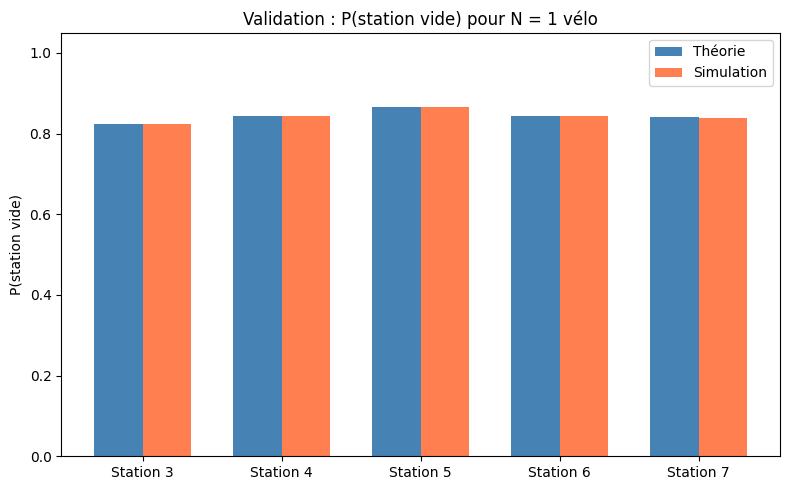

In [7]:
import matplotlib.pyplot as plt
# Graphique de validation N = 1
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(J)
width = 0.35

bars1 = ax.bar(x - width/2, th_N1, width, label='Théorie', color='steelblue')
bars2 = ax.bar(x + width/2, prob_empty_1, width, label='Simulation', color='coral')

ax.set_xticks(x)
ax.set_xticklabels([f'Station {j+3}' for j in range(J)])
ax.set_ylabel('P(station vide)')
ax.set_title('Validation : P(station vide) pour N = 1 vélo')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

On constate que les résultats obtenues par simulation coïncident parfaitement avec la théorie : la théorie nous permet donc de dire que notre simulation est correcte.

### 5.3 Simulation : $N = 100$ vélos, 5 stations

Si on voulait faire les calculs des probabilités théoriques pour N = 100 on devrait calculer : 
$$G(N) = \sum_{\mathbf{n} \in \mathcal{E}} \left[ \prod_{j \in \mathcal{S}} \alpha_j^{n_j} \prod_{(j,k) \in \mathcal{R}} \frac{\alpha_{jk}^{n_{jk}}}{n_{jk}!} \right]$$L'espace d'états $\mathcal{E}$ correspond à toutes les manières de répartir $N$ vélos indiscernables parmi $M$ composantes du réseau (ici $M = 5$ stations $+ 20$ routes $= 25$ composantes).Le cardinal de cet espace d'états est :$$\text{Card}(\mathcal{E}) = \binom{N + M - 1}{M - 1}$$

Cependant, pour $N = 100$ vélos,  le nombre d'état est:$$\text{Card}(\mathcal{E}) = \binom{100 + 25 - 1}{25 - 1} = \binom{124}{24} \approx 1,76 \times 10^{24} \text{ états}$$

Ainsi le calcul de $G(100)$ devient très complexe numériquement.

In [8]:
N_velos = 100
horizon_simulation = 500_000 

print(f"Lancement de la simulation pour N = {N_velos} vélos sur {horizon_simulation} h...")

prob_empty, avg_bikes, n_events = simulate_velib(
    N=N_velos, 
    lambda_rates=lambda_rates, 
    P_routing=P, 
    mu_routes=mu, 
    horizon=horizon_simulation,
    seed=42 
)

print(f"\n--- RÉSULTATS (Basés sur {n_events:,} événements) ---")
for i, name in enumerate(station_names):
    print(f"{name} :")
    print(f"  -> Probabilité d'être vide : {prob_empty[i]:.2%}")
    print(f"  -> Nb moyen de vélos       : {avg_bikes[i]:.1f}")
    print("-" * 35)

Lancement de la simulation pour N = 100 vélos sur 500000 h...

--- RÉSULTATS (Basés sur 17,545,817 événements) ---
Station 3 :
  -> Probabilité d'être vide : 0.02%
  -> Nb moyen de vélos       : 70.5
-----------------------------------
Station 4 :
  -> Probabilité d'être vide : 11.73%
  -> Nb moyen de vélos       : 7.6
-----------------------------------
Station 5 :
  -> Probabilité d'être vide : 23.53%
  -> Nb moyen de vélos       : 3.2
-----------------------------------
Station 6 :
  -> Probabilité d'être vide : 11.39%
  -> Nb moyen de vélos       : 7.8
-----------------------------------
Station 7 :
  -> Probabilité d'être vide : 9.36%
  -> Nb moyen de vélos       : 9.7
-----------------------------------


On constate que la station 3 est un goulot d'étranglement du système : elle accumule la majorité des vélos et n'est donc jamais vide.

Cependant, on a fait ici l'hypohtèse que les stations avaient une capacité infini (sinon, cela nous aurait obligé a gerer soit l'attente des utilisateur arrivant à une station avec leur vélo, soit la perte des vélos et la modélisation serait sortie du cadre du cours).

En pratique, ce phénomène (en moyenne 70 vélos dans la station 3) traduit une très mauvaise dimensionnement du réseau et poserait de gros problèmes : trop de vélo en station 3 et les autres stations sont vides une proportion significative du temps.

### 5.4 Calcul des intervalles de confiance par réplications indépendantes

Nous allons maintenant évaluer nos estimateurs en determinant l'intervalle de confiance a 95%.

La démarche consiste à générer $n$ trajectoires de simulation indépendantes (via des graines aléatoires distinctes), chacune d'une durée $T_{run}$ suffisamment longue pour garantir la convergence vers la distribution stationnaire.

Soit $X_i$ la statistique mesurée (par exemple, la probabilité de vacuité de la station 3) lors de la $i$-ème réplication. Les variables $X_1, X_2, \dots, X_n$ sont alors des variables aléatoires indépendantes et identiquement distribuées (i.i.d.).

Par le Théorème Central Limite, l'intervalle de confiance asymptotique à $95\%$ pour l'espérance $\mu = \mathbb{E}[X]$ est donné par :
$$I.C_{95\%} = \left[ \bar{X} - t_{1-\alpha/2, n-1} \frac{S}{\sqrt{n}} , \bar{X} + t_{1-\alpha/2, n-1} \frac{S}{\sqrt{n}} \right]$$
où :
* $\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$ est la moyenne empirique des réplications.
* $S = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{X})^2}$ est l'écart-type empirique.
* $t_{1-\alpha/2, n-1}$ est le quantile de la loi de Student à $n-1$ degrés de liberté (pour $\alpha = 0.05$).

### Remarque : 
Dans le code ci-dessous, l'optimisation pour lancer les simulations en parallèle a été géré par IA.

Note: you may need to restart the kernel to use updated packages.
Lancement de 20 simulations de 50000.0h en parallèle avec joblib...
Simulations terminées en 367.08 secondes.

=== RÉSULTATS AVEC INTERVALLES DE CONFIANCE (95%) ===
Station 3:
  P(vide) = 0.02% ± 0.01%
  Nb moyen = 70.7 ± 0.6
Station 4:
  P(vide) = 11.66% ± 0.20%
  Nb moyen = 7.6 ± 0.2
Station 5:
  P(vide) = 23.49% ± 0.16%
  Nb moyen = 3.3 ± 0.0
Station 6:
  P(vide) = 11.39% ± 0.22%
  Nb moyen = 7.7 ± 0.2
Station 7:
  P(vide) = 9.48% ± 0.17%
  Nb moyen = 9.6 ± 0.3


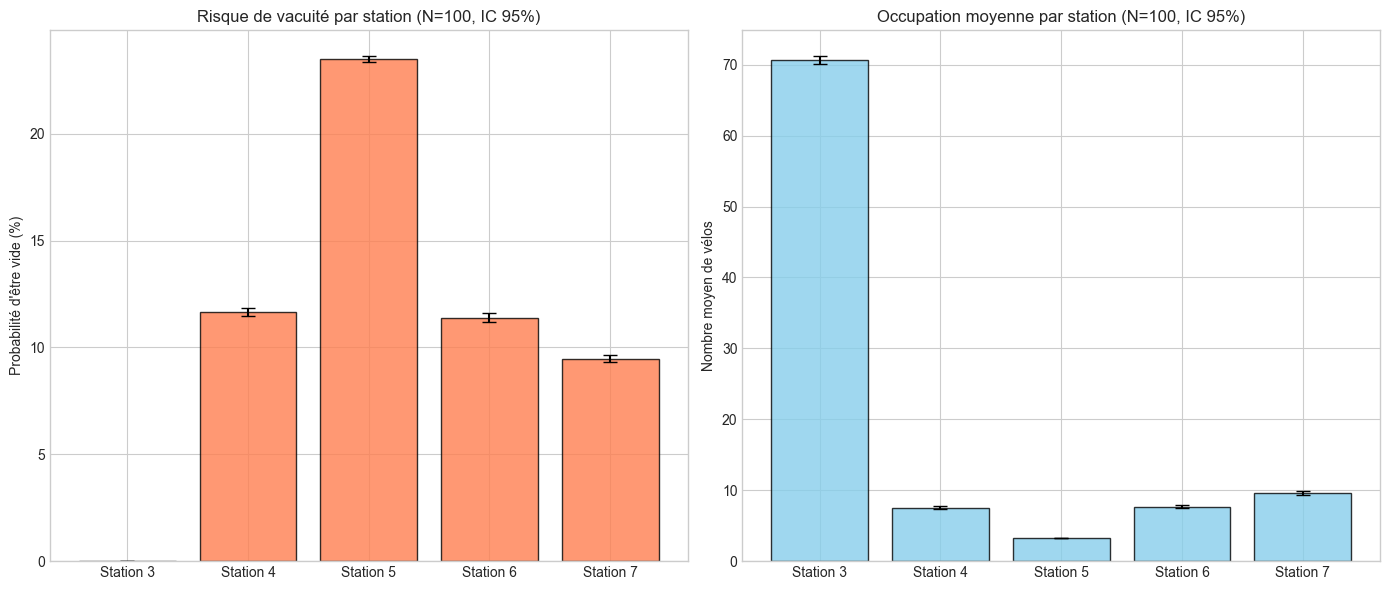

In [9]:
%pip install joblib
from scipy import stats
import time
from joblib import Parallel, delayed
# ==========================================
# 1. FONCTION WRAPPER POUR JOBLIB
# ==========================================
def run_single_simulation(seed, n_bikes, l_rates, p_mat, mu_mat, horiz):
    prob_empty, avg_bikes, _ = simulate_velib(
        N=n_bikes, 
        lambda_rates=l_rates,  
        P_routing=p_mat, 
        mu_routes=mu_mat, 
        horizon=horiz,
        seed=seed
    )
    return prob_empty, avg_bikes

# ==========================================
# 2. EXÉCUTION PARALLÈLE ET CALCUL DES IC
# ==========================================
if __name__ == "__main__":
    
    # Paramètres de l'expérience
    N_velos = 100
    n_runs = 20
    horizon_per_run = 50_000.0  
    alpha = 0.05 # IC à 95%
    seeds = [42 + i for i in range(n_runs)]
    
    print(f"Lancement de {n_runs} simulations de {horizon_per_run}h en parallèle avec joblib...")
    start_time = time.time()
    
    # Exécution parallèle (n_jobs=-1 utilise tous les processeurs logiques)
    results = Parallel(n_jobs=-1)(
        delayed(run_single_simulation)(seed, N_velos, lambda_rates, P, mu, horizon_per_run)
        for seed in seeds
    )
    
    print(f"Simulations terminées en {time.time() - start_time:.2f} secondes.")

    # Extraction des résultats (conversion de la liste de tuples en matrices Numpy)
    prob_empty_samples = np.array([res[0] for res in results])
    avg_bikes_samples = np.array([res[1] for res in results])

    # ==========================================
    # 3. STATISTIQUES (Moyenne, Ecart-type, IC)
    # ==========================================
    t_crit = stats.t.ppf(1 - alpha/2, df=n_runs - 1)

    # Statistiques Probabilité d'être vide
    mean_p_empty = np.mean(prob_empty_samples, axis=0)
    std_p_empty = np.std(prob_empty_samples, axis=0, ddof=1)
    margin_p_empty = t_crit * (std_p_empty / np.sqrt(n_runs))

    # Statistiques Nombre moyen de vélos
    mean_avg_bikes = np.mean(avg_bikes_samples, axis=0)
    std_avg_bikes = np.std(avg_bikes_samples, axis=0, ddof=1)
    margin_avg_bikes = t_crit * (std_avg_bikes / np.sqrt(n_runs))

    print("\n=== RÉSULTATS AVEC INTERVALLES DE CONFIANCE (95%) ===")
    for i, name in enumerate(station_names):
        print(f"{name}:")
        print(f"  P(vide) = {mean_p_empty[i]:.2%} ± {margin_p_empty[i]:.2%}")
        print(f"  Nb moyen = {mean_avg_bikes[i]:.1f} ± {margin_avg_bikes[i]:.1f}")

    # ==========================================
    # 4. VISUALISATIONS GRAPHIQUES
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    x_pos = np.arange(J)
    
    # Graphe 1 : Probabilités d'être vide
    ax1.bar(x_pos, mean_p_empty * 100, yerr=margin_p_empty * 100, capsize=5, color='coral', edgecolor='black', alpha=0.8)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(station_names)
    ax1.set_ylabel('Probabilité d\'être vide (%)')
    ax1.set_title(f'Risque de vacuité par station (N={N_velos}, IC 95%)')

    # Graphe 2 : Occupation moyenne
    ax2.bar(x_pos, mean_avg_bikes, yerr=margin_avg_bikes, capsize=5, color='skyblue', edgecolor='black', alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(station_names)
    ax2.set_ylabel('Nombre moyen de vélos')
    ax2.set_title(f'Occupation moyenne par station (N={N_velos}, IC 95%)')

    plt.tight_layout()
    plt.show()

### 5.5 Interprétation PASTA

Les arrivées d'usagers à chaque station $j$ forment un **processus de Poisson** de taux $\lambda_j$. Par le théorème **PASTA** (Poisson Arrivals See Time Averages), un usager arrivant à la station $j$ voit la station dans son état stationnaire, indépendamment de son instant d'arrivée.

En particulier :
$$P(\text{usager trouve la station } j \text{ vide}) = P(n_j = 0) = \hat{P}(n_j = 0)$$

**Interprétation opérationnelle :** $P(n_j = 0)$ est donc le taux de perte à la station $j$, ie. la proportion d'usagers qui arrivent et repartent sans vélo.

| Station | $\hat{P}(n_j = 0)$ | Interprétation |
|---|---|---|
| Station 3 | $\approx 0$ | Pratiquement aucun usager ne repart sans vélo |
| Station 5 | $\approx 23\%$ | Un usager sur 4 ne trouve pas de vélo |


## 6. Conclusion

Dans ce projet, nous avons modélisé un système Vélib comme un **processus de migration fermé** avec 25 colonies (5 stations à serveur unique et 20 routes à serveurs infinis).

**Résultats principaux :**

1. **Analyse théorique ($N = 1$)** : grâce au Théorème 2.4 de Kelly & Yudovina, les taux de transition étant factorisés ($q = \lambda_{c \to c'} \cdot \varphi_c(n_c)$), la distribution stationnaire s'écrit en forme produit. Nous avons calculé explicitement $P(\text{station vide})$ pour chaque station via la constante de normalisation $G(1)$.

2. **Validation** : la simulation pour $N = 1$ concorde avec les résultats théorique ce qui nous permet de valider l'algorithme de simulation pour l'étape suivante
3. **Cas $N = 100$** : le calcul exact de $G(100)$ est trop couteux ($\sim 10^{24}$ termes). La simulation Monte Carlo est donc la seule approche praticable. Les résultats montrent que Station 3 (taux de départ $\lambda_3 = 2.8$ $h^{-1}$, le plus faible) absorbe la majorité des vélos par effet de saturation : cela pose de nombreux problème de dimensionnement, notamment relatif à la capacité des staions qui n'est pas infini en réalité et aux autres stations qui se retrouvent vides.

4. **Interprétation PASTA** : les arrivées d'usagers étant des processus de Poisson, le Théorème PASTA garantit que $P(n_j = 0)$ est exactement le taux de perte opérationnel de la station $j$, ie la proportion d'usagers repartant sans vélo. On en déduit qu'au vue des paramètres du système, il y a une perte elevé d'utilisateur aux stations différentes de la 3 ce qui risque de causer du mécontentement pour les utilisateurs du services.


Une solution pour regler ce problème lié à l'utilisation du système serait de mettre en place un système de camion pour ramener les vélos de la station 3 vers les autres stations pendant la nuit.

**Perspectives :** on pourrait étendre cette analyse en considérant une **capacité finie** des stations (transformation en réseau M/M/1/K), des taux de demande variant au cours de la journée et en prenant en compte le fait que les temps de trajet ne suivent pas reellement des lois exponentielles.


## 7. Extra : Animation du système (code généré par IA)

In [ ]:
%pip install networkx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
from IPython.display import HTML

plt.rcParams['animation.embed_limit'] = 1000  # Augmente la limite à 1 GB

N_velos = 100

# --- 2. Préparation du Graphe NetworkX ---
G_nx = nx.DiGraph()
for i, name in enumerate(station_names):
    G_nx.add_node(i, name=name)
for j in range(J):
    for k in range(J):
        if j != k:
            G_nx.add_edge(j, k)

pos = nx.circular_layout(G_nx)

# --- 3. Initialisation de la figure ---
fig, ax = plt.subplots(figsize=(8, 6))  # Réduit légèrement pour alléger
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05)

# --- 4. Variables d'état ---
time_sim = 0.0
stations_anim = np.zeros(J, dtype=int)
stations_anim[0] = N_velos
routes_anim = np.zeros((J, J), dtype=int)

rng_anim = np.random.default_rng(42)
P_lambda = P * lambda_rates[:, np.newaxis]
dt_frame = 0.01

def update(frame):
    global time_sim, stations_anim, routes_anim
    
    t_end = time_sim + dt_frame
    while time_sim < t_end:
        active = (stations_anim > 0).astype(float)
        depart_rates = (active[:, np.newaxis] * P_lambda).ravel()
        arrive_rates = (routes_anim * mu).ravel()
        
        all_rates = np.concatenate([depart_rates, arrive_rates])
        total_rate = all_rates.sum()
        
        if total_rate == 0:
            break
            
        dt_event = -np.log(rng_anim.random()) / total_rate
        
        if time_sim + dt_event > t_end:
            break
            
        time_sim += dt_event
        
        probs = all_rates / total_rate
        event_idx = rng_anim.choice(len(all_rates), p=probs)
        
        n_total = J * J
        if event_idx < n_total:
            j, k = divmod(event_idx, J)
            stations_anim[j] -= 1
            routes_anim[j, k] += 1
        else:
            j, k = divmod(event_idx - n_total, J)
            routes_anim[j, k] -= 1
            stations_anim[k] += 1
            
    time_sim = t_end
    
    ax.clear()
    ax.set_title(f"Simulation Vélib' - Temps : {time_sim:.2f} heures\nFlotte : {N_velos} vélos", fontsize=14)
    ax.axis('off')
    
    node_sizes = [1500 + int(stations_anim[i]) * 50 for i in range(J)]
    node_colors = ['salmon' if stations_anim[i] == 0 else 'skyblue' for i in range(J)]
    
    edge_weights = []
    edge_colors = []
    for u, v in G_nx.edges():
        en_route = routes_anim[u, v]
        edge_weights.append(0.5 + en_route * 0.5)
        edge_colors.append('gray' if en_route == 0 else 'black')
        
    nx.draw_networkx_edges(G_nx, pos, ax=ax, width=edge_weights, edge_color=edge_colors,
                           alpha=0.6, arrows=True, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                           edgecolors='black')
    labels = {i: f"{station_names[i]}\n{int(stations_anim[i])} vélos" for i in range(J)}
    nx.draw_networkx_labels(G_nx, pos, labels, font_size=9, font_weight='bold')

# --- 5. Lancement ---
ani = animation.FuncAnimation(fig, update, frames=1000, interval=50, blit=False)
HTML(ani.to_jshtml())
